In [ ]:
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

curriculum_learner/
├── models/
│   ├── __init__.py│   
├── edgenet.py
│   ├── cornernet.py
│   ├── contournet.py
│   ├── saliencynet.py
│   ├── recognitionnet.py
│   ├── flat_model.py
├── data/
│   ├── cifar_with_edges.py
├── train_curriculum.py
├── train_flat.py
├── utils.py

train_curriculum.py (EdgeNet → CornerNet → ContourNet → SaliencyNet → RecognitionNet)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import numpy as np
import cv2
import torch.optim as optim

In [ ]:
# Directory Structure:
# curriculum_learner/
# ├── models/
# │   ├── __init__.py
# │   ├── edgenet.py
# │   ├── cornernet.py
# │   ├── contournet.py
# │   ├── saliencynet.py
# │   ├── recognitionnet.py
# │   ├── flat_model.py
# ├── data/
# │   ├── cifar_with_edges.py
# ├── train_curriculum.py
# ├── train_flat.py
# ├── utils.py


class EdgeNet(nn.Module):
    def __init__(self):
        super(EdgeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        feat = F.relu(self.conv3(x))
        edge_pred = torch.sigmoid(self.out(feat))
        return feat, edge_pred

# 2. models/cornernet.py
class CornerNet(nn.Module):
    def __init__(self):
        super(CornerNet, self).__init__()
        self.conv1 = nn.Conv2d(4, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        feat = F.relu(self.conv2(x))
        corner_pred = torch.sigmoid(self.out(feat))
        return feat, corner_pred

# 3. models/contournet.py
class ContourNet(nn.Module):
    def __init__(self):
        super(ContourNet, self).__init__()
        self.conv1 = nn.Conv2d(2, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        feat = F.relu(self.conv2(x))
        contour_pred = torch.sigmoid(self.out(feat))
        return feat, contour_pred

# 4. models/saliencynet.py
class SaliencyNet(nn.Module):
    def __init__(self):
        super(SaliencyNet, self).__init__()
        self.conv1 = nn.Conv2d(2, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        feat = F.relu(self.conv2(x))
        sal_pred = torch.sigmoid(self.out(feat))
        return feat, sal_pred

# 5. models/recognitionnet.py
class RecognitionNet(nn.Module):
    def __init__(self, num_classes):
        super(RecognitionNet, self).__init__()
        self.conv1 = nn.Conv2d(7, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# 6. models/flat_model.py
class FlatCNN(nn.Module):
    def __init__(self, num_classes):
        super(FlatCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:


class CIFARWithEdges(Dataset):
    def __init__(self, train=True):
        self.cifar = datasets.CIFAR10(root="./data", train=train, download=True)
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.cifar)

    def __getitem__(self, idx):
        image, label = self.cifar[idx]
        image_tensor = self.transform(image)

        gray = np.array(image.convert("L"))

        # Edge map using Canny
        edge = cv2.Canny(gray, 100, 200)
        edge = torch.tensor(edge / 255.0, dtype=torch.float32).unsqueeze(0)

        # Corner map using Harris
        gray_float = np.float32(gray)
        harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)
        harris = cv2.dilate(harris, None)
        corner = (harris > 0.01 * harris.max()).astype(np.float32)
        corner = torch.tensor(corner, dtype=torch.float32).unsqueeze(0)

        # Contour map using binary threshold + findContours
        _, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour_mask = np.zeros_like(gray)
        cv2.drawContours(contour_mask, contours, -1, 255, thickness=1)
        contour = torch.tensor(contour_mask / 255.0, dtype=torch.float32).unsqueeze(0)

        # Saliency map approximation using edge+corner weighted sum
        saliency = np.clip(edge.squeeze().numpy() * 0.5 + corner.squeeze().numpy() * 0.5, 0, 1)
        saliency = torch.tensor(saliency, dtype=torch.float32).unsqueeze(0)

        return image_tensor, edge, corner, contour, saliency, label


In [ ]:
class CIFAROnly(Dataset):
    def __init__(self, train=True):
        self.data = datasets.CIFAR10(root='./data', train=train, download=True)
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, label = self.data[idx]
        return self.transform(image), label


curriculum

In [ ]:
batch_size = 64
train_dataset = CIFARWithEdges(train=True)
test_dataset = CIFARWithEdges(train=False)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


100%|██████████| 170M/170M [00:12<00:00, 13.5MB/s]


In [ ]:

batch_size = 64
num_epochs = 20
num_epochs_2 = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. EdgeNet
edgenet = EdgeNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(edgenet.parameters(), lr=1e-3)

for epoch in range(num_epochs_2):
    edgenet.train()
    for images, edge_gt, _, _, _, _ in train_loader:
        images, edge_gt = images.to(device), edge_gt.to(device)
        _, edge_pred = edgenet(images)
        loss = criterion(edge_pred, edge_gt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"[EdgeNet] Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 2. CornerNet
cornernet = CornerNet().to(device)
optimizer = optim.Adam(cornernet.parameters(), lr=1e-3)

for epoch in range(num_epochs_2):
    cornernet.train()
    for images, _, corner_gt, _, _, _ in train_loader:
        images, corner_gt = images.to(device), corner_gt.to(device)
        with torch.no_grad():
            _, edge_pred = edgenet(images)
        edge_input = torch.cat([images, edge_pred], dim=1)
        _, corner_pred = cornernet(edge_input)
        loss = criterion(corner_pred, corner_gt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"[CornerNet] Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 3. ContourNet
contournet = ContourNet().to(device)
optimizer = optim.Adam(contournet.parameters(), lr=1e-3)

for epoch in range(num_epochs_2):
    contournet.train()
    for images, _, corner_gt, contour_gt, _, _ in train_loader:
        images, contour_gt = images.to(device), contour_gt.to(device)
        with torch.no_grad():
            _, edge_pred = edgenet(images)
            _, corner_pred = cornernet(torch.cat([images, edge_pred], dim=1))
        contour_input = torch.cat([edge_pred, corner_pred], dim=1)
        _, contour_pred = contournet(contour_input)
        loss = criterion(contour_pred, contour_gt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"[ContourNet] Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 4. SaliencyNet
saliencynet = SaliencyNet().to(device)
optimizer = optim.Adam(saliencynet.parameters(), lr=1e-3)

for epoch in range(num_epochs_2):
    saliencynet.train()
    for images, _, corner_gt, contour_gt, saliency_gt, _ in train_loader:
        images, saliency_gt = images.to(device), saliency_gt.to(device)
        with torch.no_grad():
            _, edge_pred = edgenet(images)
            _, corner_pred = cornernet(torch.cat([images, edge_pred], dim=1))
            _, contour_pred = contournet(torch.cat([edge_pred, corner_pred], dim=1))
        sal_input = torch.cat([corner_pred, contour_pred], dim=1)
        _, sal_pred = saliencynet(sal_input)
        loss = criterion(sal_pred, saliency_gt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"[SaliencyNet] Epoch {epoch+1}, Loss: {loss.item():.4f}")




[EdgeNet] Epoch 1, Loss: 0.1506
[EdgeNet] Epoch 2, Loss: 0.1222
[EdgeNet] Epoch 3, Loss: 0.1193
[EdgeNet] Epoch 4, Loss: 0.1300
[EdgeNet] Epoch 5, Loss: 0.1090
[EdgeNet] Epoch 6, Loss: 0.1052
[EdgeNet] Epoch 7, Loss: 0.1019
[EdgeNet] Epoch 8, Loss: 0.0839
[EdgeNet] Epoch 9, Loss: 0.0861
[EdgeNet] Epoch 10, Loss: 0.0979
[CornerNet] Epoch 1, Loss: 0.3456
[CornerNet] Epoch 2, Loss: 0.3043
[CornerNet] Epoch 3, Loss: 0.3149
[CornerNet] Epoch 4, Loss: 0.2926
[CornerNet] Epoch 5, Loss: 0.2838
[CornerNet] Epoch 6, Loss: 0.2667
[CornerNet] Epoch 7, Loss: 0.2969
[CornerNet] Epoch 8, Loss: 0.2817
[CornerNet] Epoch 9, Loss: 0.2630
[CornerNet] Epoch 10, Loss: 0.2687
[ContourNet] Epoch 1, Loss: 0.3493
[ContourNet] Epoch 2, Loss: 0.3520
[ContourNet] Epoch 3, Loss: 0.3317
[ContourNet] Epoch 4, Loss: 0.3035
[ContourNet] Epoch 5, Loss: 0.3139
[ContourNet] Epoch 6, Loss: 0.3215
[ContourNet] Epoch 7, Loss: 0.3210
[ContourNet] Epoch 8, Loss: 0.3421
[ContourNet] Epoch 9, Loss: 0.3160
[ContourNet] Epoch 10, 

In [ ]:
# 5. RecognitionNet
num_epochs = 20

recognitionnet = RecognitionNet(num_classes=10).to(device)
criterion_cls = nn.CrossEntropyLoss()
optimizer = optim.Adam(recognitionnet.parameters(), lr=1e-3)

train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    recognitionnet.train()
    running_loss = 0.0
    for images, _, _, _, _, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            _, edge_pred = edgenet(images)
            _, corner_pred = cornernet(torch.cat([images, edge_pred], dim=1))
            _, contour_pred = contournet(torch.cat([edge_pred, corner_pred], dim=1))
            _, sal_pred = saliencynet(torch.cat([corner_pred, contour_pred], dim=1))

        stacked_input = torch.cat([images, edge_pred, corner_pred, contour_pred, sal_pred], dim=1)
        logits = recognitionnet(stacked_input)
        loss = criterion_cls(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"[RecognitionNet] Epoch {epoch+1}, Loss: {loss.item():.4f}")

    recognitionnet.eval()
    total_correct = 0
    with torch.no_grad():
        for images, _, _, _, _, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            _, edge_pred = edgenet(images)
            _, corner_pred = cornernet(torch.cat([images, edge_pred], dim=1))
            _, contour_pred = contournet(torch.cat([edge_pred, corner_pred], dim=1))
            _, sal_pred = saliencynet(torch.cat([corner_pred, contour_pred], dim=1))

            stacked_input = torch.cat([images, edge_pred, corner_pred, contour_pred, sal_pred], dim=1)
            logits = recognitionnet(stacked_input)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()

    accuracy = total_correct / len(test_dataset)
    test_accuracies.append(accuracy)
    print(f"[RecognitionNet] Test Accuracy: {accuracy * 100:.2f}%")



# Final Evaluation
# recognitionnet.eval()
# total_correct = 0
# with torch.no_grad():
#     for images, _, _, _, _, labels in test_loader:
#         images, labels = images.to(device), labels.to(device)
#         _, edge_pred = edgenet(images)
#         _, corner_pred = cornernet(torch.cat([images, edge_pred], dim=1))
#         _, contour_pred = contournet(torch.cat([edge_pred, corner_pred], dim=1))
#         _, sal_pred = saliencynet(torch.cat([corner_pred, contour_pred], dim=1))

#         stacked_input = torch.cat([images, edge_pred, corner_pred, contour_pred, sal_pred], dim=1)
#         logits = recognitionnet(stacked_input)
#         preds = logits.argmax(dim=1)
#         total_correct += (preds == labels).sum().item()

# accuracy = total_correct / len(test_dataset)
# print(f"[RecognitionNet] Final Test Accuracy: {accuracy * 100:.2f}%")


[RecognitionNet] Epoch 1, Loss: 1.9628
[RecognitionNet] Test Accuracy: 39.49%
[RecognitionNet] Epoch 2, Loss: 1.5361
[RecognitionNet] Test Accuracy: 42.42%
[RecognitionNet] Epoch 3, Loss: 2.0792
[RecognitionNet] Test Accuracy: 45.48%
[RecognitionNet] Epoch 4, Loss: 1.9660
[RecognitionNet] Test Accuracy: 49.36%
[RecognitionNet] Epoch 5, Loss: 1.4803
[RecognitionNet] Test Accuracy: 49.79%
[RecognitionNet] Epoch 6, Loss: 1.1190
[RecognitionNet] Test Accuracy: 52.43%
[RecognitionNet] Epoch 7, Loss: 1.3490
[RecognitionNet] Test Accuracy: 53.43%
[RecognitionNet] Epoch 8, Loss: 1.0817
[RecognitionNet] Test Accuracy: 55.29%
[RecognitionNet] Epoch 9, Loss: 1.2203
[RecognitionNet] Test Accuracy: 54.29%
[RecognitionNet] Epoch 10, Loss: 1.1345
[RecognitionNet] Test Accuracy: 56.46%
[RecognitionNet] Epoch 11, Loss: 1.5986
[RecognitionNet] Test Accuracy: 55.79%
[RecognitionNet] Epoch 12, Loss: 1.0838
[RecognitionNet] Test Accuracy: 57.13%
[RecognitionNet] Epoch 13, Loss: 0.9333
[RecognitionNet] Test

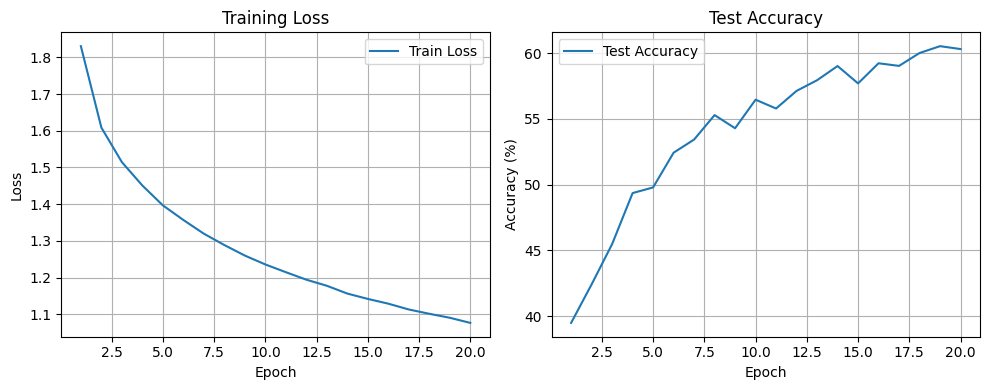

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), [acc * 100 for acc in test_accuracies], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

flat

In [ ]:


batch_size = 64
num_epochs = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load CIFAR-10 dataset (only RGB image and label used)
train_dataset_flat = CIFAROnly(train=True)
test_dataset_flat = CIFAROnly(train=False)
train_loader = DataLoader(train_dataset_flat, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset_flat, batch_size=batch_size, shuffle=False)

# Flat CNN model
model_flat = FlatCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_flat.parameters(), lr=1e-3)

train_losses = []
test_accuracies = []


# Training loop
for epoch in range(num_epochs):
    model_flat.train()
    running_loss = 0.0

    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_flat(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        total_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"[FlatCNN] Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

    # Evaluation
    model_flat.eval()
    total_correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_flat(images)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()

    accuracy = total_correct / len(test_dataset)
    test_accuracies.append(accuracy)
    print(f"FlatCNN Test Accuracy: {accuracy * 100:.2f}%")


[FlatCNN] Epoch 1, Loss: 1.8229
FlatCNN Test Accuracy: 38.98%
[FlatCNN] Epoch 2, Loss: 1.5922
FlatCNN Test Accuracy: 44.92%
[FlatCNN] Epoch 3, Loss: 1.4544
FlatCNN Test Accuracy: 50.41%
[FlatCNN] Epoch 4, Loss: 1.3743
FlatCNN Test Accuracy: 51.76%
[FlatCNN] Epoch 5, Loss: 1.3176
FlatCNN Test Accuracy: 53.10%
[FlatCNN] Epoch 6, Loss: 1.2743
FlatCNN Test Accuracy: 55.36%
[FlatCNN] Epoch 7, Loss: 1.2389
FlatCNN Test Accuracy: 56.09%
[FlatCNN] Epoch 8, Loss: 1.2025
FlatCNN Test Accuracy: 57.39%
[FlatCNN] Epoch 9, Loss: 1.1791
FlatCNN Test Accuracy: 58.52%
[FlatCNN] Epoch 10, Loss: 1.1465
FlatCNN Test Accuracy: 60.22%
[FlatCNN] Epoch 11, Loss: 1.1193
FlatCNN Test Accuracy: 60.82%
[FlatCNN] Epoch 12, Loss: 1.0972
FlatCNN Test Accuracy: 61.25%
[FlatCNN] Epoch 13, Loss: 1.0747
FlatCNN Test Accuracy: 62.00%
[FlatCNN] Epoch 14, Loss: 1.0488
FlatCNN Test Accuracy: 60.83%
[FlatCNN] Epoch 15, Loss: 1.0370
FlatCNN Test Accuracy: 63.76%
[FlatCNN] Epoch 16, Loss: 1.0182
FlatCNN Test Accuracy: 62.97%
[

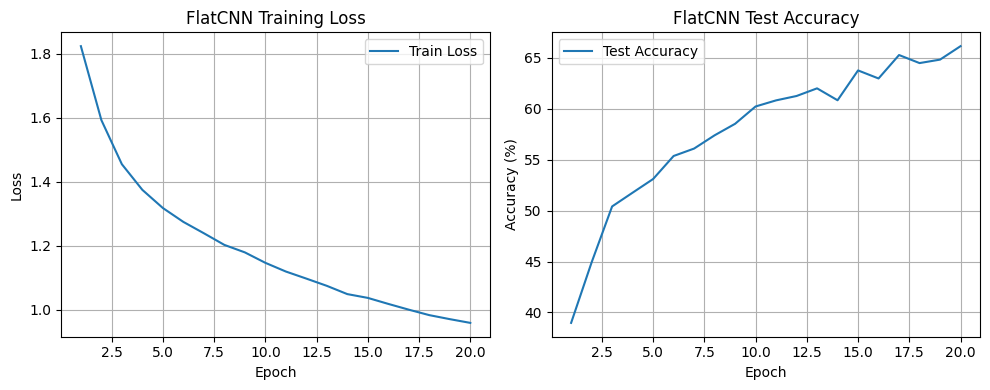

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FlatCNN Training Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), [a * 100 for a in test_accuracies], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("FlatCNN Test Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

3. Robustness: CIFAR-10-C or CIFAR-100 test

In [ ]:
# 1. Make a data directory
!mkdir -p cifar10-c
!cd cifar10-c

# 2. Download the official TAR archive from Zenodo
!wget https://zenodo.org/record/2535967/files/CIFAR-10-C.tar --no-check-certificate

# 3. Unpack it
!tar -xvf CIFAR-10-C.tar

# 4. Clean up
!rm CIFAR-10-C.tar

# 5. Go back to your script’s root
!cd ..


--2025-05-19 10:13:41--  https://zenodo.org/record/2535967/files/CIFAR-10-C.tar
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2535967/files/CIFAR-10-C.tar [following]
--2025-05-19 10:13:42--  https://zenodo.org/records/2535967/files/CIFAR-10-C.tar
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2918471680 (2.7G) [application/octet-stream]
Saving to: ‘CIFAR-10-C.tar’

CIFAR-10-C.tar      100%[===================>]   2.72G  2.84MB/s    in 21m 33s 

2025-05-19 10:35:15 (2.15 MB/s) - ‘CIFAR-10-C.tar’ saved [2918471680/2918471680]

CIFAR-10-C/
CIFAR-10-C/fog.npy
CIFAR-10-C/jpeg_compression.npy
CIFAR-10-C/zoom_blur.npy
CIFAR-10-C/speckle_noise.npy
CIFAR-10-C/glass_blur.npy
CIFAR-10-C/spatter.npy
CIFAR-10-C/shot_noise.npy
CIFAR-10-C/defocus_blur.npy

In [ ]:
import os
print(os.listdir('./cifar10-c'))
# you should see labels.npy and several .npy files like gaussian_noise.npy


In [ ]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CIFAR10C(Dataset):
    """
    CIFAR-10-C corruption dataset.
    Expects directory structure:
        ./cifar10-c/
            gaussian_noise.npy
            labels.npy
            ...
    """
    def __init__(self, root, corruption, severity=3, transform=None):
        self.root = root
        self.transform = transform or transforms.ToTensor()

        # load all images for this corruption
        all_imgs = np.load(os.path.join(root, f"{corruption}.npy"))
        all_labels = np.load(os.path.join(root, "labels.npy"))

        # CIFAR-10-C packs 10k images per severity (1–5)
        start = (severity - 1) * 10000
        end   = severity * 10000
        self.imgs   = all_imgs[start:end]
        self.labels = all_labels[start:end]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.imgs[idx]
        # CIFAR-10-C images are uint8 H×W×C
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

# --- Example evaluation loop on Gaussian Noise severity 3 ---
# (run this after training your fmodel and cmodel)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])
test_c10c = DataLoader(
    CIFAR10C(root="./CIFAR-10-C", corruption="gaussian_noise", severity=3, transform=transform),
    batch_size=64, shuffle=False
)

for model, name in [(fmodel, "Flat"), (cmodel, "Curriculum")]:
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in test_c10c:
            x, y = x.to(device), y.to(device)
            # for curriculum, build the pipeline feature stack as before
            if name == "Flat":
                out = model(x)
            else:
                # replace this with your pipeline’s forward pass
                _, ep = edgenet(x)
                _, cp = cornernet(torch.cat([x, ep], 1))
                _, cont = contournet(torch.cat([ep, cp], 1))
                _, sal = saliencynet(torch.cat([cp, cont], 1))
                stacked = torch.cat([x, ep, cp, cont, sal], 1)
                out = recognitionnet(stacked)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
    acc = correct / len(test_c10c.dataset) * 100
    print(f"{name} on CIFAR-10-C (gaussian_noise, sev=3): {acc:.2f}%")


NameError: name 'fmodel' is not defined

1. Data-Efficiency: accuracy vs. training‐set size

In [ ]:
import sys
sys.path.append('/mnt/data')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt


# --- Helpers ---
def make_subset_loader(dataset_cls, fraction, batch_size, train=True):
    dataset = dataset_cls(train=train)
    n = len(dataset)
    keep = int(n * fraction)
    subset, _ = random_split(dataset, [keep, n - keep])
    return DataLoader(subset, batch_size=batch_size, shuffle=True)

def train_flat(model, train_loader, test_loader, device, epochs=10):
    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(model.parameters(), lr=1e-3)
    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = crit(out, y)
            opt.zero_grad()
            loss.backward()
            opt.step()
    # eval
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
    return correct / len(test_loader.dataset)

def train_pipeline(train_loader, test_loader, device,
                   epochs_stage=10, epochs_rec=20):
    # 1) EdgeNet
    enet = EdgeNet().to(device)
    opt_e = optim.Adam(enet.parameters(), lr=1e-3)
    crit_bce = nn.BCELoss()
    for _ in range(epochs_stage):
        enet.train()
        for imgs, edge_gt, _, _, _, _ in train_loader:
            imgs, edge_gt = imgs.to(device), edge_gt.to(device)
            _, epred = enet(imgs)
            loss = crit_bce(epred, edge_gt)
            opt_e.zero_grad(); loss.backward(); opt_e.step()

    # 2) CornerNet
    cnet = CornerNet().to(device)
    opt_c = optim.Adam(cnet.parameters(), lr=1e-3)
    for _ in range(epochs_stage):
        cnet.train()
        for imgs, _, corn_gt, _, _, _ in train_loader:
            imgs = imgs.to(device); corn_gt = corn_gt.to(device)
            with torch.no_grad():
                _, epred = enet(imgs)
            _, cpred = cnet(torch.cat([imgs, epred], dim=1))
            loss = crit_bce(cpred, corn_gt)
            opt_c.zero_grad(); loss.backward(); opt_c.step()

    # 3) ContourNet
    conet = ContourNet().to(device)
    opt_cn = optim.Adam(conet.parameters(), lr=1e-3)
    for _ in range(epochs_stage):
        conet.train()
        for imgs, _, corn_gt, cont_gt, _, _ in train_loader:
            imgs, cont_gt = imgs.to(device), cont_gt.to(device)
            with torch.no_grad():
                _, epred = enet(imgs)
                _, cpred = cnet(torch.cat([imgs, epred], dim=1))
            _, cont_pred = conet(torch.cat([epred, cpred], dim=1))
            loss = crit_bce(cont_pred, cont_gt)
            opt_cn.zero_grad(); loss.backward(); opt_cn.step()

    # 4) SaliencyNet
    snet = SaliencyNet().to(device)
    opt_s = optim.Adam(snet.parameters(), lr=1e-3)
    crit_mse = nn.MSELoss()
    for _ in range(epochs_stage):
        snet.train()
        for imgs, _, _, _, sal_gt, _ in train_loader:
            imgs, sal_gt = imgs.to(device), sal_gt.to(device)
            with torch.no_grad():
                _, epred = enet(imgs)
                _, cpred = cnet(torch.cat([imgs, epred], dim=1))
                _, cont_pred = conet(torch.cat([epred, cpred], dim=1))
            _, sal_pred = snet(torch.cat([cpred, cont_pred], dim=1))
            loss = crit_mse(sal_pred, sal_gt)
            opt_s.zero_grad(); loss.backward(); opt_s.step()

    # 5) RecognitionNet
    rnet = RecognitionNet(num_classes=10).to(device)
    opt_r = optim.Adam(rnet.parameters(), lr=1e-3)
    crit_xe = nn.CrossEntropyLoss()
    for _ in range(epochs_rec):
        rnet.train()
        for imgs, _, _, _, _, labs in train_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            with torch.no_grad():
                _, epred = enet(imgs)
                _, cpred = cnet(torch.cat([imgs, epred], dim=1))
                _, cont_pred = conet(torch.cat([epred, cpred], dim=1))
                _, sal_pred = snet(torch.cat([cpred, cont_pred], dim=1))
            stacked = torch.cat([imgs, epred, cpred, cont_pred, sal_pred], dim=1)
            logits = rnet(stacked)
            loss = crit_xe(logits, labs)
            opt_r.zero_grad(); loss.backward(); opt_r.step()

    # final eval
    rnet.eval()
    correct = 0
    with torch.no_grad():
        for imgs, _, _, _, _, labs in test_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            _, ep = enet(imgs)
            _, cp = cnet(torch.cat([imgs, ep], dim=1))
            _, cont = conet(torch.cat([ep, cp], dim=1))
            _, sal = snet(torch.cat([cp, cont], dim=1))
            stacked = torch.cat([imgs, ep, cp, cont, sal], dim=1)
            preds = rnet(stacked).argmax(1)
            correct += (preds == labs).sum().item()
    return correct / len(test_loader.dataset)


# -------- Run Data‐Efficiency --------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fractions = [0.1, 0.25, 0.5, 1.0]
batch_size = 64

flat_acc = []
pipe_acc = []

test_flat_loader = DataLoader(CIFAROnly(train=False), batch_size=batch_size, shuffle=False)
test_pipe_loader = DataLoader(CIFARWithEdges(train=False), batch_size=batch_size, shuffle=False)

for frac in fractions:
    # Flat CNN
    floader = make_subset_loader(CIFAROnly, frac, batch_size, train=True)
    model_flat = FlatCNN(num_classes=10).to(device)
    acc_f = train_flat(model_flat, floader, test_flat_loader, device, epochs=10)
    flat_acc.append(acc_f)

    # Curriculum pipeline
    ploader = make_subset_loader(CIFARWithEdges, frac, batch_size, train=True)
    acc_p = train_pipeline(ploader, test_pipe_loader, device,
                           epochs_stage=5, epochs_rec=10)
    pipe_acc.append(acc_p)

# Plot comparison
plt.plot([f*100 for f in fractions], [a*100 for a in flat_acc], marker='o', label='Flat CNN')
plt.plot([f*100 for f in fractions], [a*100 for a in pipe_acc], marker='o', label='Curriculum')
plt.xlabel('Percent of Training Data')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()


###################

In [ ]:
# Complete pipeline vs. flat-benchmark script

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from ptflops import get_model_complexity_info



# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------
# Helpers
# ---------------------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_m(params):
    return sum(p.numel() for p in params if p.requires_grad) / 1e6

def make_subset_loader(ds_cls, fraction, batch_size, train=True):
    ds = ds_cls(train=train)
    n = len(ds)
    k = int(n * fraction)
    sub, _ = random_split(ds, [k, n - k])
    return DataLoader(sub, batch_size=batch_size, shuffle=True)

def train_flat(model, train_loader, test_loader, device, epochs=10):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
    # eval
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
    return correct / len(test_loader.dataset)

def train_pipeline(train_loader, test_loader, device,
                   epochs_stage=1, epochs_rec=8):
    # Stage nets
    enet = EdgeNet().to(device)
    cnet = CornerNet().to(device)
    conet = ContourNet().to(device)
    snet = SaliencyNet().to(device)
    rnet = RecognitionNet(num_classes=10).to(device)

    # Train each stage briefly (1 epoch each by default)
    bce = nn.BCELoss()
    for net, loader, key in [
        (enet,  ('edge',), epochs_stage),
        (cnet,  ('corner',), epochs_stage),
        (conet, ('contour',), epochs_stage),
        (snet,  ('saliency',), epochs_stage),
    ]:
        opt = optim.Adam(net.parameters(), lr=1e-3)
        for _ in range(key):
            net.train()
            for batch in train_loader:
                imgs = batch[0].to(device)
                gt = batch[list(batch._fields).index(key[0])].to(device)
                with torch.no_grad():
                    # for corner/contour/saliency, chain previous nets
                    if key[0] != 'edge':
                        _, ep = enet(imgs)
                        if key[0] == 'corner':
                            inp = torch.cat([imgs, ep], 1)
                        elif key[0] == 'contour':
                            _, cp = cnet(torch.cat([imgs, ep], 1))
                            inp = torch.cat([ep, cp], 1)
                        else:  # saliency
                            _, cp = cnet(torch.cat([imgs, ep], 1))
                            _, ct = conet(torch.cat([ep, cp], 1))
                            inp = torch.cat([cp, ct], 1)
                    else:
                        inp = imgs
                _, pred = net(inp)
                loss = bce(pred, gt)
                opt.zero_grad(); loss.backward(); opt.step()

    # RecognitionNet training
    opt_r = optim.Adam(rnet.parameters(), lr=1e-3)
    xe = nn.CrossEntropyLoss()
    for _ in range(epochs_rec):
        rnet.train()
        for imgs, edge_gt, corn_gt, cont_gt, sal_gt, labs in train_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            with torch.no_grad():
                _, ep = enet(imgs)
                _, cp = cnet(torch.cat([imgs, ep],1))
                _, ct = conet(torch.cat([ep, cp],1))
                _, sal = snet(torch.cat([cp, ct],1))
            stack = torch.cat([imgs, ep, cp, ct, sal],1)
            loss = xe(rnet(stack), labs)
            opt_r.zero_grad(); loss.backward(); opt_r.step()

    # Evaluate recognition
    rnet.eval()
    correct = 0
    with torch.no_grad():
        for imgs, _, _, _, _, labs in test_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            _, ep = enet(imgs)
            _, cp = cnet(torch.cat([imgs, ep],1))
            _, ct = conet(torch.cat([ep, cp],1))
            _, sal = snet(torch.cat([cp, ct],1))
            stack = torch.cat([imgs, ep, cp, ct, sal],1)
            correct += (rnet(stack).argmax(1) == labs).sum().item()
    return correct / len(test_loader.dataset)

def train_pipeline_balanced(train_loader, test_loader, device, total_epochs=10, stage_frac=0.2):
    # allocate epochs
    stage_total = max(int(total_epochs * stage_frac), 1)
    per_stage = max(stage_total // 4, 1)
    rec_epochs = total_epochs - per_stage * 4
    return train_pipeline(train_loader, test_loader, device,
                          epochs_stage=per_stage, epochs_rec=rec_epochs)

class HierPipeline(nn.Module):
    def __init__(self, enet, cnet, conet, snet, rnet):
        super().__init__()
        self.enet, self.cnet = enet, cnet
        self.conet, self.snet = conet, snet
        self.rnet             = rnet

    def forward(self, x):
        _, ep = self.enet(x)
        _, cp = self.cnet(torch.cat([x, ep],1))
        _, ct = self.conet(torch.cat([ep, cp],1))
        _, sal= self.snet(torch.cat([cp, ct],1))
        return self.rnet(torch.cat([x, ep, cp, ct, sal],1))

# ---------------------
# Main
# ---------------------
if __name__ == "__main__":
    batch_size = 64
    # Parameter counts
    print("Param counts (M):")
    nets = {
        "FlatCNN": FlatCNN(10),
        "EdgeNet": EdgeNet(),
        "CornerNet": CornerNet(),
        "ContourNet": ContourNet(),
        "SaliencyNet": SaliencyNet(),
        "RecNet": RecognitionNet(10),
    }
    total = 0
    for name, net in nets.items():
        mcount = count_m(net.parameters())
        print(f"  {name}: {mcount:.2f}M")
        if name != "FlatCNN":
            total += mcount
    print(f"  Total pipeline: {total:.2f}M\n")

    # Dataset loaders
    test_flat = DataLoader(CIFAROnly(train=False), batch_size=batch_size, shuffle=False)
    test_pipe = DataLoader(CIFARWithEdges(train=False), batch_size=batch_size, shuffle=False)
    train_flat_loader = DataLoader(CIFAROnly(train=True), batch_size=batch_size, shuffle=True)
    train_pipe_loader = DataLoader(CIFARWithEdges(train=True), batch_size=batch_size, shuffle=True)

    # Timing
    start = time.time()
    acc_f = train_flat(FlatCNN(10), train_flat_loader, test_flat, device, epochs=10)
    print(f"Flat CNN 10-epoch acc: {acc_f*100:.2f}%, time: {time.time()-start:.1f}s")

    start = time.time()
    acc_p = train_pipeline_balanced(train_pipe_loader, test_pipe, device, total_epochs=10, stage_frac=0.2)
    print(f"Pipeline bal 10-epoch acc: {acc_p*100:.2f}%, time: {time.time()-start:.1f}s\n")

    # FLOPs
    macs_f, params_f = get_model_complexity_info(FlatCNN(10).to(device),
                                                 (3,32,32), as_strings=False, print_per_layer_stat=False)
    macs_p, _        = get_model_complexity_info(
        HierPipeline(EdgeNet(), CornerNet(), ContourNet(), SaliencyNet(), RecognitionNet(10)).to(device),
        (3,32,32), as_strings=False, print_per_layer_stat=False
    )
    print(f"Flat CNN FLOPs: {macs_f/1e9:.2f} GFLOPs")
    print(f"Pipeline FLOPs: {macs_p/1e9:.2f} GFLOPs")


In [ ]:
import matplotlib.pyplot as plt

# Epochs from 1 to 20
epochs = list(range(1, 21))

# Accuracy data extracted
acc_data = {
    'rgb': [35.19, 40.33, 44.22, 45.63, 48.28, 48.70, 50.16, 51.05, 53.35, 53.64, 54.37, 54.22, 54.18, 54.73, 55.51, 55.04, 57.04, 56.99, 56.02, 57.88],
    'corner': [37.65, 42.45, 44.91, 46.86, 47.87, 49.99, 50.89, 52.39, 53.20, 54.24, 55.47, 53.08, 56.46, 56.50, 57.69, 57.89, 57.90, 57.51, 59.00, 58.18],
    'contour': [35.68, 38.27, 43.64, 46.83, 48.07, 49.59, 50.48, 51.14, 50.97, 52.28, 53.82, 53.03, 55.10, 55.60, 54.89, 56.49, 55.60, 56.79, 56.63, 56.85],
    'saliency': [38.06, 40.66, 42.07, 45.93, 47.37, 50.56, 51.42, 52.52, 53.55, 53.95, 53.80, 54.27, 56.63, 56.55, 56.71, 57.90, 57.89, 57.56, 58.88, 59.88],
    'rgb_edge': [37.79, 40.46, 42.56, 44.95, 48.21, 49.72, 50.06, 50.96, 52.62, 53.26, 54.19, 54.44, 55.03, 54.58, 56.19, 55.79, 57.31, 56.85, 57.59, 56.52],
    'all': [36.91, 43.86, 46.54, 46.78, 49.65, 52.13, 52.68, 51.53, 54.97, 55.44, 56.04, 57.27, 56.38, 56.98, 57.58, 57.25, 59.47, 58.48, 58.98, 59.25]
}

plt.figure()
for variant, acc in acc_data.items():
    plt.plot(epochs, acc, label=variant)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Ablation Study: Accuracy over Epochs')
plt.legend()
plt.tight_layout()
plt.show()
